In [1]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer,RobertaTokenizerFast


In [2]:
dataset = load_dataset("evalitahf/sentiment_analysis")
dataset['train'][0]

{'idtwitter': '122449983151669248',
 'subj': '1',
 'opos': '0',
 'oneg': '1',
 'iro': '0',
 'lpos': '0',
 'lneg': '1',
 'top': '1',
 'text': 'Intanto la partita per Via Nazionale si complica. #Saccomanni dice che "mica tutti sono Mario #Monti" <URL> via <MENTION_1>'}

## Definiamo il dataset per avere il sentimeni neutro, positivo, negativo

In [4]:
class SentipolcDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len=128):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, item):
        row = self.dataset[item]
        text = str(row['text']) 
        
        # encode_plus gestisce tutto: padding, troncamento e token speciali
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',      # Padding automatico a 128
            truncation=True,          # Troncamento automatico
            return_attention_mask=True,
            return_tensors='pt'       # Restituisce tensori PyTorch
        )
        
        # Mapping etichette
        opos = int(row['opos'])
        oneg = int(row['oneg'])
        label = 1 if opos == 1 else (2 if oneg == 1 else 0)
            
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [5]:
# Inizializzazione
model_name = "dbmdz/bert-base-italian-xxl-cased"
#model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
#tokenizer = RobertaTokenizerFast.from_pretrained(model_name, add_prefix_space=True)
train_ds = SentipolcDataset(dataset['train'], tokenizer) 
test_ds = SentipolcDataset(dataset['test'], tokenizer) 
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [7]:
#Scarichiamo il modello preaddestrato con un head di classificazione sul primo token CLS
from transformers import BertForSequenceClassification,AutoModelForSequenceClassification,RobertaForSequenceClassification
from torch.optim import AdamW
import torch
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3, # Neutro, Positivo, Negativo,
    classifier_dropout = 0.4,
    hidden_dropout_prob=0.15,      # Default è 0.1
    attention_probs_dropout_prob=0.15,
attn_implementation="eager")
# model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=3,
#     classifier_dropout=0.1
# )
model.to(device)

# Definiamo i parametri da escludere dal weight decay (bias e layer normalization)
# Il weight decay è una tecnica di regolarizzazione dei pesi che fa si che la loro magnitudo non esploda 
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], 'weight_decay': 0.2},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], 'weight_decay': 0.2}
]
optimizer = AdamW(optimizer_grouped_parameters, lr=3e-5)
epochs = 6
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=46, num_training_steps=total_steps)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dbmdz/bert-base-italian-xxl-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Definiamo la funzione di valutazione del modello

In [8]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate(model, data_loader, device):
    model.eval()
    predictions = []
    actual_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)
            
            predictions.extend(preds.cpu().tolist())
            actual_labels.extend(labels.cpu().tolist())
            
    acc = accuracy_score(actual_labels, predictions)
    f1 = f1_score(actual_labels, predictions, average='weighted')
    return acc, f1

In [9]:
from tqdm.auto import tqdm


for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    # Avvolgiamo il train_loader con tqdm
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}", unit="batch")
    
    for batch in progress_bar:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        
        loss = outputs.loss
        total_loss += loss.item()
        
        # Predizioni per accuracy
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        # Aggiorniamo le info sulla barra di caricamento in tempo reale
        current_acc = total_correct / total_samples
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{current_acc:.4f}"})
        
    avg_train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_samples
    
    print(f"\n[RIEPILOGO EPOCA {epoch + 1}] Loss media: {avg_train_loss:.4f} | Accuracy: {train_acc:.4f}")
    
    val_acc, val_f1 = evaluate(model, test_loader, device)
    print(f"Validation -> Acc: {val_acc:.4f}, F1: {val_f1:.4f}\n")

Epoch 1/6:   0%|          | 0/464 [00:00<?, ?batch/s]


[RIEPILOGO EPOCA 1] Loss media: 0.8804 | Accuracy: 0.5798
Validation -> Acc: 0.6825, F1: 0.6766



Epoch 2/6:   0%|          | 0/464 [00:00<?, ?batch/s]


[RIEPILOGO EPOCA 2] Loss media: 0.6377 | Accuracy: 0.7425
Validation -> Acc: 0.6505, F1: 0.6329



Epoch 3/6:   0%|          | 0/464 [00:00<?, ?batch/s]


[RIEPILOGO EPOCA 3] Loss media: 0.4340 | Accuracy: 0.8382
Validation -> Acc: 0.6430, F1: 0.6178



Epoch 4/6:   0%|          | 0/464 [00:00<?, ?batch/s]

KeyboardInterrupt: 

## Visualizziamo le attention maps:

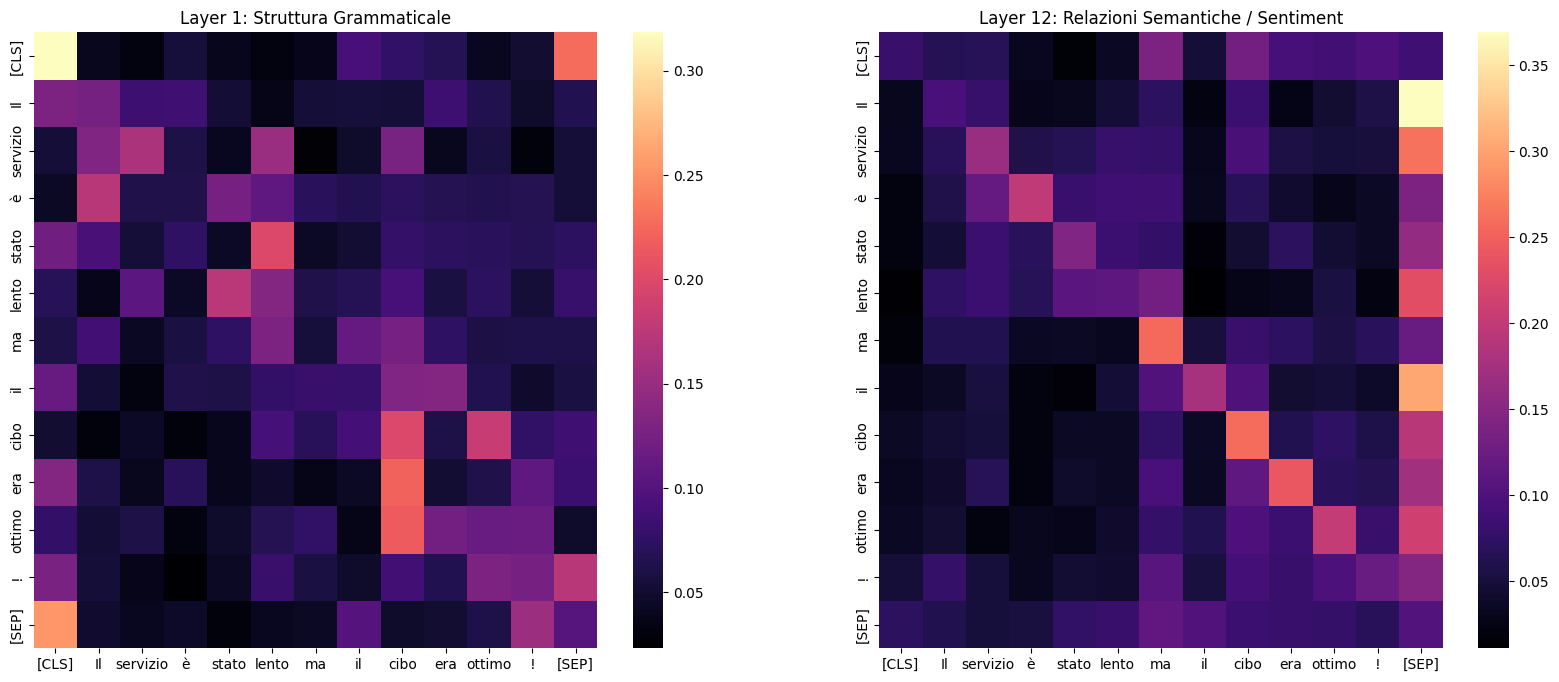

In [11]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_comparison(text, model, tokenizer, device):
    inputs = tokenizer(text, return_tensors="pt", max_length=64, truncation=True, padding='max_length').to(device)
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # Prendiamo i token per le etichette
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    last_idx = (inputs['input_ids'][0] != tokenizer.pad_token_id).sum().item()
    
    # Estraiamo Layer 1 (indice 0) e Layer 12 (indice 11)
    # Usiamo la media di tutte le 12 teste per avere una visione d'insieme del layer
    att_layer_1 = outputs.attentions[0][0].mean(dim=0).cpu().numpy()[:last_idx, :last_idx]
    att_layer_12 = outputs.attentions[11][0].mean(dim=0).cpu().numpy()[:last_idx, :last_idx]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(att_layer_1, xticklabels=tokens[:last_idx], yticklabels=tokens[:last_idx], cmap='magma', ax=ax1)
    ax1.set_title("Layer 1: Struttura Grammaticale")
    
    sns.heatmap(att_layer_12, xticklabels=tokens[:last_idx], yticklabels=tokens[:last_idx], cmap='magma', ax=ax2)
    ax2.set_title("Layer 12: Relazioni Semantiche / Sentiment")
    plt.savefig('attention_maps.png')
    plt.show()

# Prova con una frase carica di significato
plot_attention_comparison("Il servizio è stato lento ma il cibo era ottimo!", model, tokenizer, device)

In [12]:
def predict_sentiment(text, model, tokenizer, device):
    model.eval()
    # Tokenizzazione manuale come fatto nel Dataset
    tokens = tokenizer.encode(
        text, 
        add_special_tokens=True, 
        max_length=128, 
        truncation=True
    )
    
    padding_length = 128 - len(tokens)
    input_ids = torch.tensor([tokens + ([tokenizer.pad_token_id] * padding_length)]).to(device)
    attention_mask = torch.tensor([([1] * len(tokens)) + ([0] * padding_length)]).to(device)
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred_class = torch.argmax(probs, dim=1).item()
    
    mapping = {0: "Neutro/Misto", 1: "Positivo", 2: "Negativo"}
    return mapping[pred_class], probs[0][pred_class].item()

# Esempio di test
frase = "Questo governo sta facendo un lavoro ottimo, che bello!"
sentiment, confidence = predict_sentiment(frase, model, tokenizer, device)
print(f"Test: {frase}\nRisultato: {sentiment} ({confidence*100:.2f}%)")

Test: Questo governo sta facendo un lavoro ottimo, che bello!
Risultato: Positivo (93.91%)


In [15]:
test_frasi = [
    "Finalmente una bella notizia per l'Italia, avanti così!", # Positivo chiaro
    "Non ne posso più di questi ritardi infiniti, vergognatevi.", # Negativo chiaro
    "Il servizio è stato... interessante. Non credo tornerò mai più.", # Negativo/Sarcasmo
    "Si parla di nuove tasse nella prossima manovra economica.", # Neutro/Informativo
    "Ma sì, certo, un altro aumento dei prezzi era proprio quello che ci serviva! #ironia" # Ironico/Negativo
]

print(f"{'FRASE':<60} | {'PREDIZIONE':<15} | {'CONFIDENZA'}")
print("-" * 90)

for f in test_frasi:
    res, conf = predict_sentiment(f, model, tokenizer, device)
    print(f"{f[:58]:<60} | {res:<15} | {conf:.2%}")

FRASE                                                        | PREDIZIONE      | CONFIDENZA
------------------------------------------------------------------------------------------
Finalmente una bella notizia per l'Italia, avanti così!      | Positivo        | 96.54%
Non ne posso più di questi ritardi infiniti, vergognatevi.   | Negativo        | 97.53%
Il servizio è stato... interessante. Non credo tornerò mai   | Positivo        | 90.32%
Si parla di nuove tasse nella prossima manovra economica.    | Neutro/Misto    | 86.48%
Ma sì, certo, un altro aumento dei prezzi era proprio quel   | Positivo        | 50.92%
